Data shape: (45211, 9)


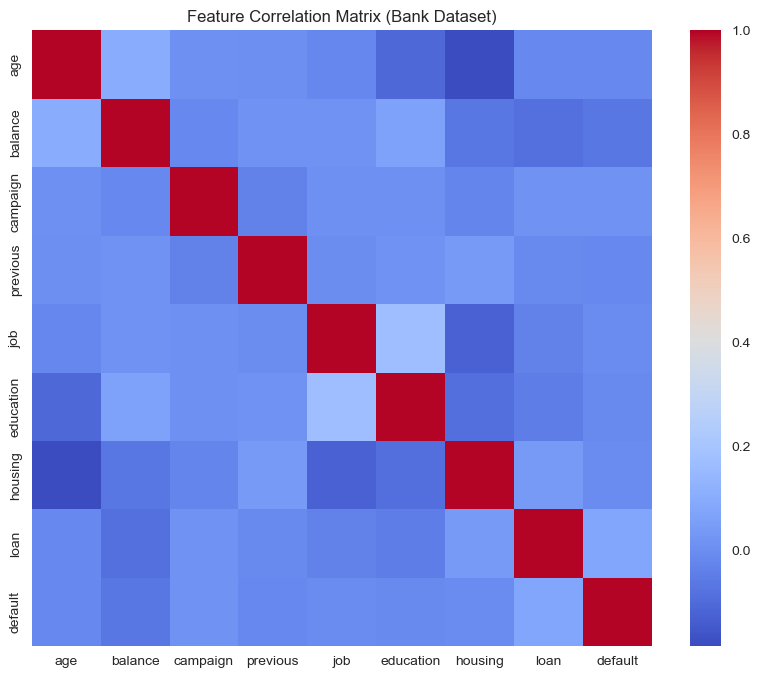

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
%matplotlib inline

def load_data(filepath):
    """Load and preprocess the bank marketing dataset.

    Steps:
    - Load the CSV (semicolon-separated)
    - Label-encode categorical columns
    - Scale numerical features with StandardScaler
    """
    df = pd.read_csv(filepath, sep=';')

    categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                        'loan', 'contact', 'month', 'poutcome', 'y']
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])

    features = ['age', 'balance', 'campaign', 'previous', 'job', 'education',
                'housing', 'loan', 'default']
    X = df[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, df

# Load and preprocess the data
X_scaled, data = load_data('bank-full.csv')
print("Data shape:", X_scaled.shape)

# Create a DataFrame with scaled features for correlation visualization
corr_features = ['age','balance','campaign','previous','job','education','housing','loan','default']
corr_df = pd.DataFrame(X_scaled, columns=corr_features)

# Plot correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix (Bank Dataset)")
plt.show()


In [11]:
class KMeansClustering:
    """Simple K-means implementation suitable for the lab.

    This implementation is intentionally straightforward and deterministic
    given a `random_state`. It implements the usual steps: initialize centroids,
    assign points to nearest centroid, update centroids, and stop when centroids
    stop moving (below a small threshold) or `max_iters` is reached.
    """
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def _initialize_centroids(self, X):
        """Initialize centroids by sampling `n_clusters` unique points from X."""
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]
        if self.n_clusters > n_samples:
            raise ValueError('n_clusters must be <= number of samples')
        idx = rng.choice(n_samples, size=self.n_clusters, replace=False)
        return X[idx].astype(float)

    def _assign_clusters(self, X):
        """Assign each sample to the nearest centroid (Euclidean distance)."""
        distances = np.linalg.norm(X[:, None, :] - self.centroids[None, :, :], axis=2)
        labels = distances.argmin(axis=1)
        return labels

    def _update_centroids(self, X, labels):
        """Compute new centroids as the mean of points in each cluster."""
        n_features = X.shape[1]
        new_centroids = np.zeros((self.n_clusters, n_features), dtype=float)
        rng = np.random.RandomState(self.random_state)
        for k in range(self.n_clusters):
            members = X[labels == k]
            if len(members) == 0:
                # Reinitialize empty cluster centroid to a random existing sample
                new_centroids[k] = X[rng.randint(0, X.shape[0])]
            else:
                new_centroids[k] = members.mean(axis=0)
        return new_centroids

    def fit(self, X):
        """Run K-means until convergence or `max_iters`."""
        X = np.asarray(X, dtype=float)
        self.centroids = self._initialize_centroids(X)
        for i in range(self.max_iters):
            labels = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, labels)
            shift = np.linalg.norm(self.centroids - new_centroids)
            self.centroids = new_centroids
            self.labels = labels
            if shift < 1e-4:
                break
        return self

    def predict(self, X):
        """Assign cluster labels to X using learned centroids."""
        if self.centroids is None:
            raise ValueError("Model has not been fitted yet. Call fit(X) first.")
        return self._assign_clusters(X)


## 2. Dimensionality Reduction

Before clustering, we often reduce the dimensionality of our data for better visualization and performance. Implement PCA below:

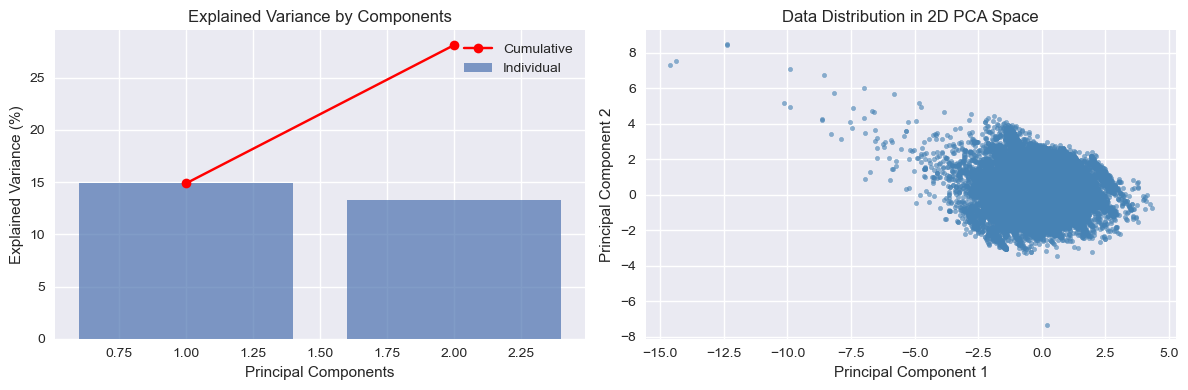

Shape after PCA: (45211, 2)


In [16]:
def apply_pca(X, n_components=2):
    """Apply PCA for dimensionality reduction.

    TODO:
    1. Initialize and fit PCA
    2. Transform the data
    3. Create visualizations to understand:
       - Explained variance ratio
       - Cumulative explained variance
       - Data distribution in 2D
    """
    # Your code here:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # ✅ TODO: Create visualization
    plt.figure(figsize=(12, 4))

    # Plot explained variance
    plt.subplot(1, 2, 1)
    explained_var = pca.explained_variance_ratio_ * 100
    cum_var = np.cumsum(explained_var)
    plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, label='Individual')
    plt.plot(range(1, len(cum_var) + 1), cum_var, color='red', marker='o', label='Cumulative')
    plt.xlabel("Principal Components")
    plt.ylabel("Explained Variance (%)")
    plt.title("Explained Variance by Components")
    plt.legend()

    # ✅ Plot data in 2D
    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.6, c='steelblue')
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("Data Distribution in 2D PCA Space")

    plt.tight_layout()
    plt.show()

    return X_pca

# Apply PCA
X_pca = apply_pca(X_scaled)
print("Shape after PCA:", X_pca.shape)


## 3. Clustering Evaluation

Implement functions to evaluate the quality of your clustering results:

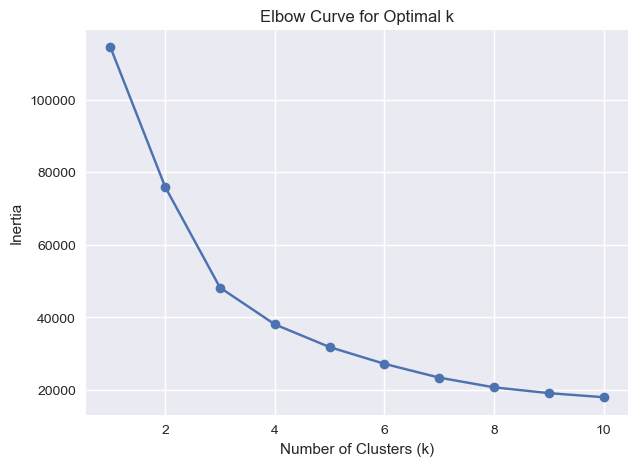

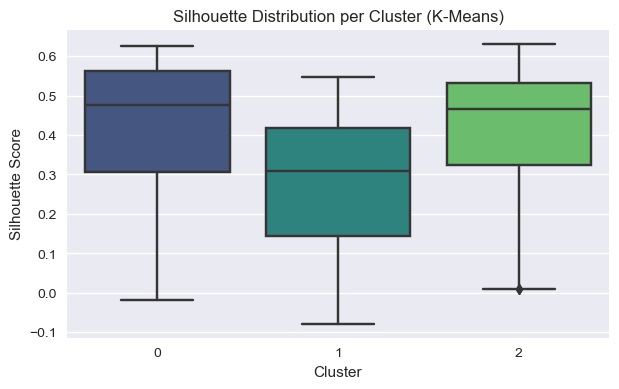

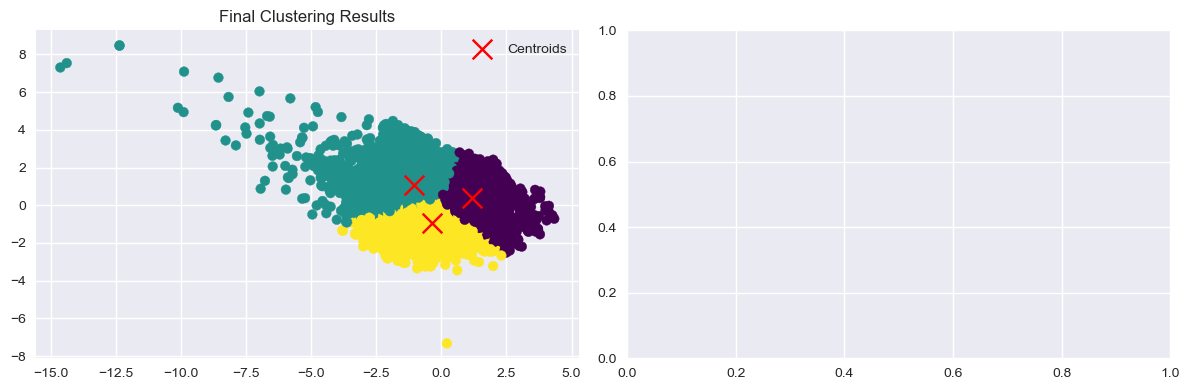


Clustering Evaluation:
Inertia: 48179.64
Silhouette Score: 0.39


In [17]:
def calculate_inertia(X, labels, centroids):
    """Calculate the within-cluster sum of squares (inertia).

    TODO:
    1. For each cluster, calculate the sum of squared distances
       between points and their centroid
    2. Sum up all cluster distances
    """
    # Your code here
    inertia = 0
    # Calculate distances between points and their assigned centroids
    for k in range(len(centroids)):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            distances = np.linalg.norm(cluster_points - centroids[k], axis=1)
            inertia += np.sum(distances ** 2)
    return inertia


def plot_elbow_curve(X, max_k=10):
    """Plot the elbow curve to find optimal number of clusters.

    TODO:
    1. Try different values of k (1 to max_k)
    2. Calculate inertia for each k
    3. Plot k vs inertia
    4. Help identify the 'elbow' point
    """
    # Your code here
    inertias = []
    K = range(1, max_k + 1)

    # Calculate inertia for different k values
    for k in K:
        kmeans = KMeansClustering(n_clusters=k)
        kmeans.fit(X)
        inertia = calculate_inertia(X, kmeans.labels, kmeans.centroids)
        inertias.append(inertia)

    # Create elbow plot
    plt.figure(figsize=(7,5))
    plt.plot(K, inertias, marker='o')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Curve for Optimal k")
    plt.grid(True)
    plt.show()

    return inertias


# Try different numbers of clusters
inertias = plot_elbow_curve(X_pca)

from sklearn.metrics import silhouette_samples

# Compute silhouette scores for each sample
silhouette_vals = silhouette_samples(X_pca, kmeans.labels)

# Create boxplot to visualize silhouette distribution
plt.figure(figsize=(7,4))
sns.boxplot(x=kmeans.labels, y=silhouette_vals, palette='viridis')
plt.title("Silhouette Distribution per Cluster (K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Silhouette Score")
plt.show()

# Apply final clustering
kmeans = KMeansClustering(n_clusters=3)  # Try different values based on elbow curve
kmeans.fit(X_pca)

# Visualize final results
plt.figure(figsize=(12, 4))

# Plot clusters
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='x', s=200, label='Centroids')
plt.title('Final Clustering Results')
plt.legend()

# Plot evaluation metrics
plt.subplot(1, 2, 2)
# Your code here: Add relevant evaluation metric plots

plt.tight_layout()
plt.show()

# Calculate and print evaluation metrics
inertia = calculate_inertia(X_pca, kmeans.labels, kmeans.centroids)
silhouette = silhouette_score(X_pca, kmeans.labels)

print("\nClustering Evaluation:")
print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.2f}")

## 4. Recursive Bisecting K-means (Student exercise)

This is an optional exercise for students who want to explore a hierarchical variant of K-means.

Task: implement a concise bisecting K-means procedure that recursively splits clusters into two until a target number of clusters is reached.

Learning goals:
- Understand how repeated binary splits can form a hierarchical clustering
- Practice applying K-means on subclusters and tracking labels/centroids

Hints:
- You can use sklearn's KMeans(k=2) for the binary split step, or reuse your `KMeansClustering` implementation.
- Keep label bookkeeping simple: use increasing integer labels for new clusters.
- Store split metadata (parent -> left/right) to enable a tree visualization later.

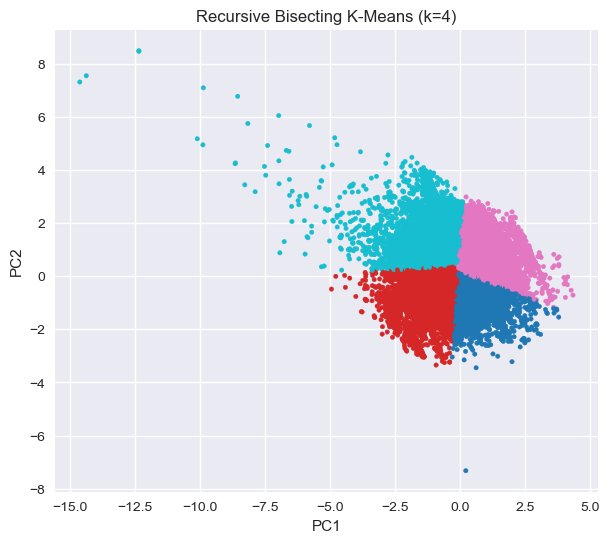

Split hierarchy: {0: (0, 2), 1: (1, 3)}


In [18]:
from sklearn.cluster import KMeans

class BisectingKMeans:
    """Concise skeleton for students to implement a bisecting K-means algorithm.

    Students should implement `fit_predict` to recursively split clusters until
    `n_clusters` is reached.
    """
    def __init__(self, n_clusters, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.labels_ = None
        # Optional: store mapping parent -> (left_label, right_label)
        self.split_tree = {}
        # Optional: store centroids per cluster id
        self.centers_ = {}

    def fit_predict(self, X):
        """Recursively bisect clusters until `n_clusters` is reached.

        TODO (student):
        - Start with all points assigned to label 0.
        - While number of unique labels < n_clusters:
            - Select a cluster to split (e.g., the largest cluster by size)
            - Run a binary KMeans (k=2) on the points in that cluster
            - Assign new labels (keep one child label as the original, give the other a new id)
            - Record parent -> (left, right) in `self.split_tree` and centroids in `self.centers_`
        - Set and return `self.labels_` (numpy array of length n_samples)
        """
        # ✅ Start with all samples in one cluster labeled 0
        n_samples = X.shape[0]
        labels = np.zeros(n_samples, dtype=int)
        current_k = 1  # number of current clusters
        next_label_id = 1  # counter for new cluster ids

        # Initialize first centroid
        self.centers_[0] = np.mean(X, axis=0)

        # ✅ Keep splitting until target cluster count reached
        while current_k < self.n_clusters:
            # 1️⃣ Select the largest cluster by number of samples
            unique_labels, counts = np.unique(labels, return_counts=True)
            largest_cluster = unique_labels[np.argmax(counts)]

            # 2️⃣ Extract points belonging to this cluster
            cluster_indices = np.where(labels == largest_cluster)[0]
            X_subset = X[cluster_indices]

            # If cluster has fewer than 2 points, can't split
            if len(X_subset) < 2:
                break

            # 3️⃣ Apply KMeans (k=2) to the selected cluster
            km = KMeans(n_clusters=2, random_state=self.random_state)
            subset_labels = km.fit_predict(X_subset)

            # 4️⃣ Assign new labels
            # One child keeps the parent label; the other gets a new label id
            left_indices = cluster_indices[subset_labels == 0]
            right_indices = cluster_indices[subset_labels == 1]

            labels[left_indices] = largest_cluster
            labels[right_indices] = next_label_id

            # 5️⃣ Store metadata (parent split info)
            self.split_tree[largest_cluster] = (largest_cluster, next_label_id)
            self.centers_[largest_cluster] = km.cluster_centers_[0]
            self.centers_[next_label_id] = km.cluster_centers_[1]

            # 6️⃣ Update counters
            current_k += 1
            next_label_id += 1

        # ✅ Store final labels and return
        self.labels_ = labels
        return self.labels_

# Run Bisecting KMeans
bisect = BisectingKMeans(n_clusters=4, random_state=42)
labels_bisect = bisect.fit_predict(X_pca)

# Visualize results
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_bisect, cmap='tab10', s=10)
plt.title("Recursive Bisecting K-Means (k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Inspect split tree
print("Split hierarchy:", bisect.split_tree)

## Bonus Challenges

If you've completed the main tasks, try these extensions:

1. Implement k-means++ initialization
   - Instead of random initialization, use the k-means++ algorithm
   - This should give better and more consistent results

2. Add cluster interpretation
   - Analyze the characteristics of each cluster
   - What features distinguish one cluster from another?
   - Create visualizations to show cluster properties

3. Try different distance metrics
   - Implement Manhattan distance instead of Euclidean
   - Compare the clustering results

4. Add outlier detection
   - Identify points far from all centroids
   - How might you handle these outliers?

Remember to document your code and explain your findings!